In [1]:
import pandas as pd
from preprocess import prepare_for_quantile_transformer
from Transformer_model import QuantileEncoderDecoderTransformer, train_one_epoch, evaluate
from Transformer_model import build_cfg_from_prepared
from typing import Dict, Any, Optional, Tuple
import os, json, pickle
from dataclasses import asdict
import numpy as np
import matplotlib.pyplot as plt
import torch
import time

In [38]:
df = pd.read_csv("raw_data/raw_data_merged.csv")
last_day = df.tail(96)["isp"]

In [40]:
last_day

34272    104.2733
34273     82.4400
34274     74.1200
34275     48.1050
34276     69.6457
           ...   
34363     92.8360
34364    107.9510
34365    113.1610
34366    117.1490
34367     80.0650
Name: isp, Length: 96, dtype: float64

In [ ]:
df["isp"] = (
    pd.to_numeric(df["isp"], errors="coerce")
    .clip(lower=-500, upper=500)
)
from preprocess import split_last_full_days
df_cut, last = split_last_full_days(df)
prepared = prepare_for_quantile_transformer(
    df=df_cut,
    target_col="isp",
    L=96 * 7,  # napr. 7 dní histórie (7*96 = 672)
    H=96,  # 1 deň dopredu
)

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
cfg = build_cfg_from_prepared(
    prepared,
    horizon=96,
    use_known_future=True,
    crossing_penalty_weight=0.0,
)

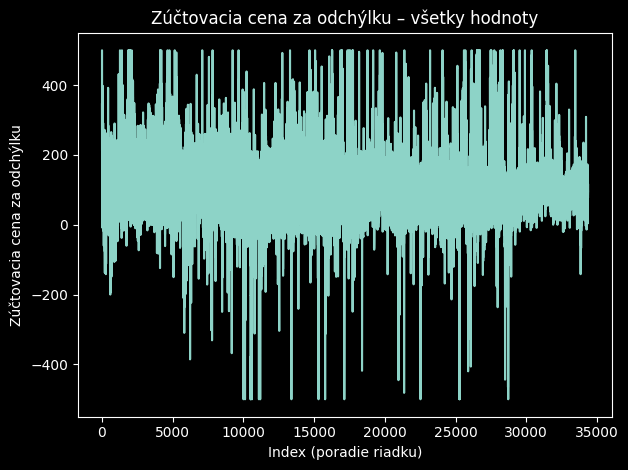

In [5]:
y = pd.to_numeric(df["isp"], errors="coerce").dropna()

plt.figure()
plt.plot(y.values)  # x = 0..N-1, y = hodnoty
plt.xlabel("Index (poradie riadku)")
plt.ylabel("Zúčtovacia cena za odchýlku")
plt.title("Zúčtovacia cena za odchýlku – všetky hodnoty")
plt.tight_layout()
plt.show()

In [6]:
def save_bundle(
        path: str,
        model: torch.nn.Module,
        cfg,  # QuantileTransformerConfig
        feature_cols: Dict[str, Any],
        scalers: Dict[str, Any],
        extra: Optional[Dict[str, Any]] = None,
) -> None:
    """
    Uloží:
      - model.state_dict()
      - cfg (asdict)
      - feature_cols (napr. prepared.feature_cols)
      - scalers (prepared.scalers) cez pickle
      - extra metadata (voliteľné)
    """
    os.makedirs(path, exist_ok=True)

    # 1) model weights
    torch.save(model.state_dict(), os.path.join(path, "model_state.pt"))

    # 2) cfg + feature cols + extra do JSON
    meta = {
        "cfg": asdict(cfg),
        "feature_cols": feature_cols,
        "extra": extra or {},
    }
    with open(os.path.join(path, "meta.json"), "w", encoding="utf-8") as f:
        json.dump(meta, f, ensure_ascii=False, indent=2)

    # 3) scalers pickle
    with open(os.path.join(path, "scalers.pkl"), "wb") as f:
        pickle.dump(scalers, f, protocol=pickle.HIGHEST_PROTOCOL)


def load_bundle(
        path: str,
        model_class,  # QuantileEncoderDecoderTransformer
        cfg_class,  # QuantileTransformerConfig
        device: torch.device,
) -> Tuple[torch.nn.Module, Any, Dict[str, Any], Dict[str, Any]]:
    """
    Načíta bundle a vráti: (model, cfg, feature_cols, scalers)
    """
    meta_path = os.path.join(path, "meta.json")
    state_path = os.path.join(path, "model_state.pt")
    scalers_path = os.path.join(path, "scalers.pkl")

    if not os.path.exists(meta_path) or not os.path.exists(state_path) or not os.path.exists(scalers_path):
        raise FileNotFoundError(f"Missing bundle files in: {path}")

    with open(meta_path, "r", encoding="utf-8") as f:
        meta = json.load(f)

    cfg = cfg_class(**meta["cfg"])
    feature_cols = meta["feature_cols"]

    with open(scalers_path, "rb") as f:
        scalers = pickle.load(f)

    model = model_class(cfg).to(device)
    state = torch.load(state_path, map_location=device)
    model.load_state_dict(state)
    model.eval()

    return model, cfg, feature_cols, scalers


In [7]:
bundle_dir = "artifacts/qt_transformer_v1"

In [8]:
model = QuantileEncoderDecoderTransformer(cfg).to(device)

opt = torch.optim.AdamW(model.parameters(), lr=3e-4)


def format_seconds(s: float) -> str:
    m = int(s // 60)
    sec = s - 60 * m
    return f"{m:02d}:{sec:04.1f}"


def train_model(
        model,
        prepared,
        cfg,
        device,
        epochs: int = 10,
        lr: float = 3e-4,
        grad_clip: float = 1.0,
        bundle_dir: Optional[str] = None,
):
    """
    Trénuje model a (voliteľne) ukladá najlepší checkpoint podľa val loss.

    Vypisované metriky:
      - train_loss: priemerný pinball loss (a prípadne crossing penalty) na tréningových batchoch
      - val_loss:   to isté na validačných batchoch
      - best_val:   najlepšia validačná hodnota doteraz
    """
    model = model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr)

    best_val = float("inf")

    print("Training started")
    print(f"  epochs        : {epochs}")
    print(f"  lr            : {lr}")
    print(f"  grad_clip     : {grad_clip}")
    print(f"  horizon (H)   : {cfg.horizon}")
    print(f"  quantiles (Q) : {len(cfg.quantiles)} -> {list(cfg.quantiles)}")
    print(f"  scale_target  : {'y' in prepared.scalers} (loss is computed on scaled target if True)")
    print("-" * 90)
    print(
        f"{'epoch':>5} | {'train_loss':>10} | {'val_loss':>10} | {'best_val':>10} | {'Δ val':>10} | {'time':>7} | note"
    )
    print("-" * 90)

    for epoch in range(epochs):
        t0 = time.time()

        tr = train_one_epoch(model, prepared.train_loader, opt, device, grad_clip=grad_clip)
        va = evaluate(model, prepared.val_loader, device)

        dt = time.time() - t0
        delta = va - best_val

        improved = va < best_val
        note = "✅ improved" if improved else "—"

        if improved:
            best_val = va
            delta_str = f"{delta: .3e}" if epoch > 0 else "   n/a"
            # uložiť checkpoint iba pri zlepšení
            if bundle_dir is not None:
                save_bundle(
                    path=bundle_dir,
                    model=model,
                    cfg=cfg,
                    feature_cols=prepared.feature_cols,
                    scalers=prepared.scalers,
                    extra={
                        "best_val": float(best_val),
                        "epoch": int(epoch),
                        "target_col": prepared.feature_cols["target"][0],
                        "L": int(prepared.arrays["train"]["X_hist"].shape[1]),
                        "H": int(cfg.horizon),
                        "notes": "Quantile encoder-decoder transformer (best checkpoint)",
                    },
                )
        else:
            delta_str = f"{delta: .3e}"

        print(
            f"{epoch:5d} | {tr:10.6f} | {va:10.6f} | {best_val:10.6f} | {delta_str:>10} | {format_seconds(dt):>7} | {note}"
        )

    print("-" * 90)
    print(f"Done. Best val_loss = {best_val:.6f}")
    return best_val


/home/mremen/.virtualenvs/transformer/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [9]:
best_val = train_model(
    model=model,
    prepared=prepared,
    cfg=cfg,
    device=device,
    epochs=20,
    lr=3e-4,
    grad_clip=1.0,
    bundle_dir=bundle_dir,  # ukladá len keď sa zlepší
)

Training started
  epochs        : 20
  lr            : 0.0003
  grad_clip     : 1.0
  horizon (H)   : 96
  quantiles (Q) : 9 -> [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
  scale_target  : True (loss is computed on scaled target if True)
------------------------------------------------------------------------------------------
epoch | train_loss |   val_loss |   best_val |      Δ val |    time | note
------------------------------------------------------------------------------------------
    0 |   1.019243 |   5.524649 |   5.524649 |        n/a | 00:32.4 | ✅ improved
    1 |   0.467298 |   3.420616 |   3.420616 | -2.104e+00 | 00:32.0 | ✅ improved
    2 |   0.319192 |   3.379896 |   3.379896 | -4.072e-02 | 00:32.0 | ✅ improved
    3 |   0.234565 |   2.949199 |   2.949199 | -4.307e-01 | 00:32.0 | ✅ improved
    4 |   0.215146 |   3.001984 |   2.949199 |  5.279e-02 | 00:32.0 | —
    5 |   0.213780 |   3.091267 |   2.949199 |  1.421e-01 | 00:32.0 | —
    6 |   0.211749 |   2.994612 |

In [10]:
# # po treningu
# save_bundle(
#     path=bundle_dir,
#     model=model,
#     cfg=cfg,
#     feature_cols=prepared.feature_cols,
#     scalers=prepared.scalers,
#     extra={
#         "target_col": "isp",
#         "L": 96 * 7,
#         "H": 96,
#         "notes": "Quantile encoder-decoder transformer",
#     }
# )
print("Saved to:", bundle_dir)
print(f"Model initialized with {sum(p.numel() for p in model.parameters()):,} parameters")

Saved to: artifacts/qt_transformer_v1
Model initialized with 1,874,953 parameters


In [11]:
def _inverse_scale_y(y_scaled: np.ndarray, y_scaler) -> np.ndarray:
    if y_scaler is None:
        return y_scaled
    shp = y_scaled.shape
    flat = y_scaled.reshape(-1, 1)
    inv = y_scaler.inverse_transform(flat).reshape(shp)
    return inv

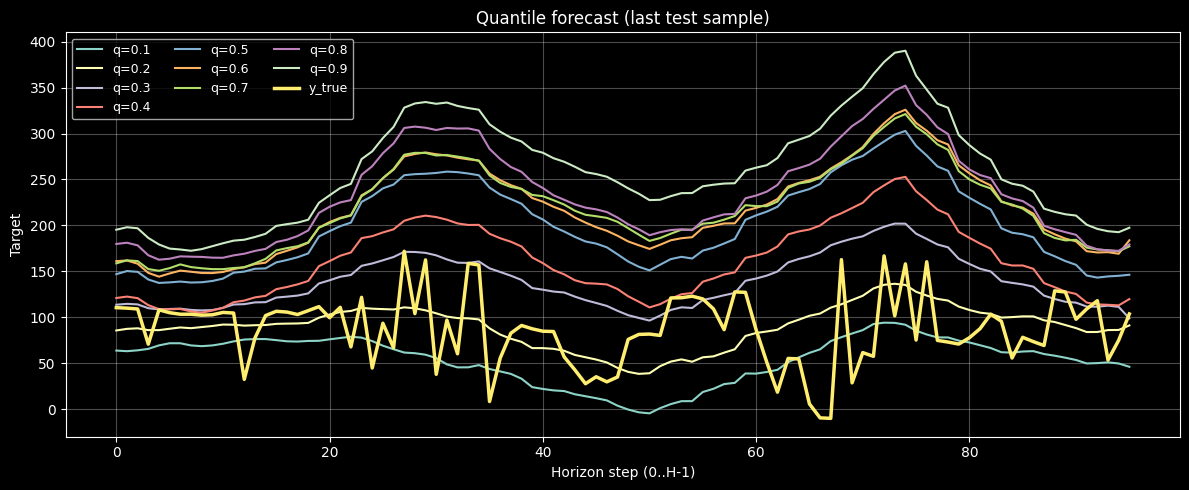

In [12]:
@torch.no_grad()
def predict_one_sample(
        model,
        prepared,
        device,
        split: str = "test",
        sample_idx: int = -1,  # -1 = posledný sample
):
    """
    Vráti (yhat_q, y_true) v *pôvodných jednotkách*.
    yhat_q: (H, Q)
    y_true: (H,)
    """
    model.eval()

    arrays = prepared.arrays[split]
    X_hist = arrays["X_hist"]
    X_fut = arrays["X_fut"]
    Y_fut = arrays["Y_fut"]

    # vyber sample
    x_hist = X_hist[sample_idx]  # (L, d_enc)
    y_true = Y_fut[sample_idx]  # (H,)
    x_fut = None if X_fut is None else X_fut[sample_idx]  # (H, d_dec)

    # torch batch dim
    x_hist_t = torch.from_numpy(x_hist).unsqueeze(0).to(device)  # (1,L,d_enc)
    x_fut_t = None if x_fut is None else torch.from_numpy(x_fut).unsqueeze(0).to(device)

    # forward
    yhat_q_t = model(x_hist_t, x_fut_t)  # (1,H,Q)
    yhat_q = yhat_q_t.squeeze(0).detach().cpu().numpy()  # (H,Q)

    # inverse scale target
    y_scaler = prepared.scalers.get("y", None)
    yhat_q = _inverse_scale_y(yhat_q, y_scaler)  # (H,Q)
    y_true = _inverse_scale_y(y_true, y_scaler)  # (H,)

    return yhat_q, y_true


def plot_quantile_forecast(
        yhat_q: np.ndarray,
        quantiles,
        y_true: np.ndarray = None,
        title: str = "Quantile forecast",
):
    """
    yhat_q: (H, Q)
    quantiles: list/array length Q
    y_true: (H,) optional
    """
    H, Q = yhat_q.shape
    x = np.arange(H)

    plt.figure(figsize=(12, 5))
    # kvantilové krivky
    for j, q in enumerate(quantiles):
        plt.plot(x, yhat_q[:, j], label=f"q={q:.1f}")

    # skutočnosť
    if y_true is not None:
        plt.plot(x, y_true, linewidth=2.5, label="y_true")

    plt.title(title)
    plt.xlabel("Horizon step (0..H-1)")
    plt.ylabel("Target")
    plt.legend(ncol=3, fontsize=9)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# --- použitie (ak už máš model a prepared) ---
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

yhat_q, y_true = predict_one_sample(model, prepared, device, split="test", sample_idx=-1)

quantiles = list(cfg.quantiles)  # alebo model.quantiles.cpu().numpy().tolist()
plot_quantile_forecast(
    yhat_q=yhat_q,
    quantiles=quantiles,
    y_true=y_true,
    title="Quantile forecast (last test sample)",
)


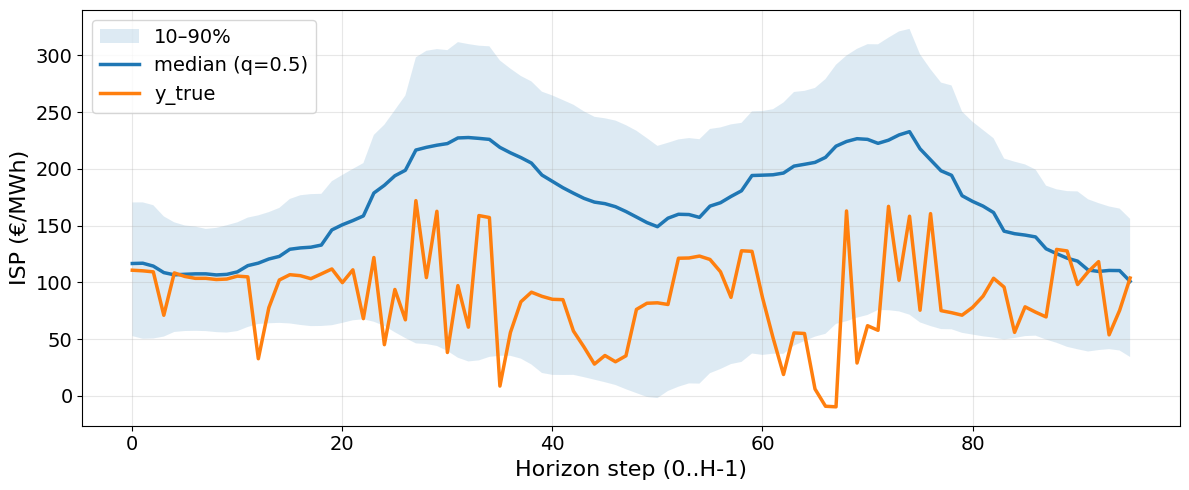

In [54]:
def plot_fan_chart(yhat_q: np.ndarray, quantiles, y_true: np.ndarray = None, title= ""):
    H, Q = yhat_q.shape
    x = np.arange(H)

    q = np.array(quantiles)

    def get_q(level):
        j = int(np.where(np.isclose(q, level))[0][0])
        return yhat_q[:, j]

    q10 = get_q(0.1);
    q25 = get_q(0.2) if 0.2 in q else None
    q50 = get_q(0.5);
    q75 = get_q(0.8) if 0.8 in q else None
    q90 = get_q(0.9)

    plt.figure(figsize=(12, 5))
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    # pásma
    plt.fill_between(x, q10, q90, alpha=0.15, label="10–90%")
    # medián
    plt.plot(x, q50, linewidth=2.5, label="median (q=0.5)")

    if y_true is not None:
        plt.plot(x, y_true, linewidth=2.5, label="y_true")

    plt.title(title)
    plt.xlabel("Horizon step (0..H-1)", fontsize=16)
    plt.ylabel("ISP (€/MWh)",fontsize=16)
    plt.legend(fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_fan_chart(yhat_q, quantiles, y_true)


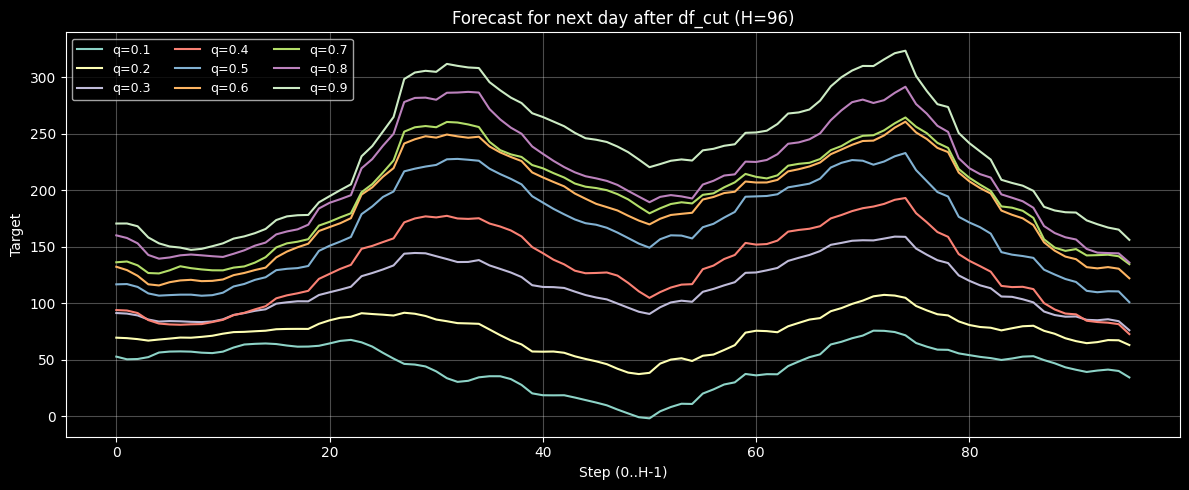

In [14]:
from preprocess import add_time_features_15min, add_lag_features


@torch.no_grad()
def predict_next_day_from_dfcut(work_df_cut: pd.DataFrame, prepared, model, cfg, device,
                                period_col="period_end", tz=None):
    """
    Vezme posledné okno z df_cut a predikuje ďalších H krokov.
    Vracia yhat_q (H,Q) v pôvodných jednotkách.
    """
    # Urob rovnaké feature engineering kroky ako v prepare_for_quantile_transformer,
    # ale použijeme presne tie stĺpce, ktoré si mal uložené v prepared.feature_cols.
    tmp = work_df_cut.copy()
    tmp[period_col] = pd.to_datetime(tmp[period_col])
    tmp = tmp.sort_values(period_col).set_index(period_col)

    # replikujeme minimum z prepare:
    if "Stav sustavy" in tmp.columns and tmp["Stav sustavy"].dtype == object:
        dummies = pd.get_dummies(tmp["Stav sustavy"], prefix="state", dtype=np.float32)
        tmp = tmp.drop(columns=["Stav sustavy"]).join(dummies)

    tmp = add_time_features_15min(tmp, tz=tz)
    tmp = add_lag_features(tmp, target_col=prepared.feature_cols["target"][0])

    enc_cols = prepared.feature_cols["enc"]
    dec_cols = prepared.feature_cols["dec"]
    L = cfg.horizon * 7  # u teba 96*7; ak chceš presne, môžeš ho uložiť do extra a čítať odtiaľ

    # Pozor: L nevieme z cfg, takže lepšie zober z prepared:
    L = prepared.arrays["train"]["X_hist"].shape[1]
    H = cfg.horizon

    tmp = tmp.dropna()
    if len(tmp) < L:
        raise ValueError("Not enough rows after feature engineering/dropna for last window.")

    # posledné historické okno
    X_hist_last = tmp[enc_cols].to_numpy(dtype=np.float32)[-L:]  # (L, d_enc)

    # budúce kovariáty (kalendár) na nasledujúcich H krokov:
    # vytvoríme budúci index po konci df_cut
    last_ts = tmp.index[-1]
    freq = pd.infer_freq(tmp.index) or "15min"
    fut_index = pd.date_range(last_ts + pd.Timedelta(freq), periods=H, freq=freq)

    fut_df = pd.DataFrame(index=fut_index)
    fut_df = add_time_features_15min(fut_df, tz=tz)
    X_fut_last = fut_df[dec_cols].to_numpy(dtype=np.float32)  # (H, d_dec)

    # škálovanie podľa prepared.scalers
    if "enc" in prepared.scalers:
        enc_scaler = prepared.scalers["enc"]
        X_hist_last = enc_scaler.transform(X_hist_last)

    if "dec" in prepared.scalers and X_fut_last is not None:
        dec_scaler = prepared.scalers["dec"]
        X_fut_last = dec_scaler.transform(X_fut_last)

    # torch + forward
    xh = torch.from_numpy(X_hist_last).unsqueeze(0).to(device)  # (1,L,d_enc)
    xf = torch.from_numpy(X_fut_last).unsqueeze(0).to(device)  # (1,H,d_dec)

    yhat_q = model(xh, xf).squeeze(0).cpu().numpy()  # (H,Q)

    # inverse scale y
    y_scaler = prepared.scalers.get("y", None)
    yhat_q = _inverse_scale_y(yhat_q, y_scaler)

    return fut_index, yhat_q


def plot_quantiles(yhat_q: np.ndarray, quantiles, title="Quantile forecast"):
    H, Q = yhat_q.shape
    x = np.arange(H)
    plt.figure(figsize=(12, 5))
    for j, q in enumerate(quantiles):
        plt.plot(x, yhat_q[:, j], label=f"q={q:.1f}")
    plt.title(title)
    plt.xlabel("Step (0..H-1)")
    plt.ylabel("Target")
    plt.grid(True, alpha=0.3)
    plt.legend(ncol=3, fontsize=9)
    plt.tight_layout()
    plt.show()


fut_index, yhat_q = predict_next_day_from_dfcut(df_cut, prepared, model, cfg, device, tz=None)
plot_quantiles(yhat_q, list(cfg.quantiles), title="Forecast for next day after df_cut (H=96)")

In [15]:
import numpy as np
import torch


@torch.no_grad()
def test_bias_summary(model, prepared, device, q=0.5):
    model.eval()
    q_list = model.quantiles.detach().cpu().numpy().tolist()
    j = int(np.where(np.isclose(q_list, q))[0][0])

    y_scaler = prepared.scalers.get("y", None)

    diffs = []
    for batch in prepared.test_loader:
        if len(batch) == 2:
            x_hist, y_true = batch
            x_fut = None
        else:
            x_hist, x_fut, y_true = batch
            x_fut = x_fut.to(device)

        x_hist = x_hist.to(device)
        y_true = y_true.to(device)

        yhat_q = model(x_hist, x_fut)  # (B,H,Q)
        yhat = yhat_q[..., j].detach().cpu().numpy()
        yt = y_true.detach().cpu().numpy()

        # inverse scale
        if y_scaler is not None:
            yhat = _inverse_scale_y(yhat, y_scaler)
            yt = _inverse_scale_y(yt, y_scaler)

        diffs.append((yhat - yt).reshape(-1))

    diffs = np.concatenate(diffs)
    print("median error (q50):", np.median(diffs))
    print("mean error (q50):  ", np.mean(diffs))
    print("% under (q50):     ", np.mean(diffs < 0))


test_bias_summary(model, prepared, device, q=0.5)


median error (q50): 45.831753
mean error (q50):   282476.2
% under (q50):      0.24883996212121212


In [16]:
@torch.no_grad()
def coverage_check(model, prepared, device, tau=0.9):
    q_list = model.quantiles.detach().cpu().numpy().tolist()
    i_tau = int(np.where(np.isclose(q_list, tau))[0][0])

    y_scaler = prepared.scalers.get("y", None)
    covered = []

    for batch in prepared.test_loader:
        if len(batch) == 2:
            x_hist, y_true = batch
            x_fut = None
        else:
            x_hist, x_fut, y_true = batch
            x_fut = x_fut.to(device)

        x_hist = x_hist.to(device)
        y_true = y_true.to(device)

        yhat_q = model(x_hist, x_fut).detach().cpu().numpy()
        yt = y_true.detach().cpu().numpy()
        y_tau = yhat_q[..., i_tau]

        if y_scaler is not None:
            yt = _inverse_scale_y(yt, y_scaler)
            y_tau = _inverse_scale_y(y_tau, y_scaler)

        covered.append((yt <= y_tau).reshape(-1))

    covered = np.concatenate(covered)
    cov = covered.mean()
    print(f"Coverage for q{tau:.1f} = {cov:.4f} (ideal ~{tau:.2f})")

In [17]:
y_scaler = prepared.scalers.get("y", None)

train_y = prepared.arrays["train"]["Y_fut"]
test_y = prepared.arrays["test"]["Y_fut"]

train_y = _inverse_scale_y(train_y, y_scaler)
test_y = _inverse_scale_y(test_y, y_scaler)

print("train median:", np.median(train_y), " test median:", np.median(test_y))
print("train mean:  ", np.mean(train_y), " test mean:  ", np.mean(test_y))


train median: 84.9361  test median: 99.41
train mean:   98.5374  test mean:   108.46105


In [18]:

def plot_fan_chart(
        yhat_q: np.ndarray,
        quantiles,
        y_true: np.ndarray = None,
        title: str = "Quantile fan chart",
        ax=None,
):
    """
    yhat_q: (H,Q)
    y_true: (H,) alebo None
    """
    H, Q = yhat_q.shape
    x = np.arange(H)

    q = np.array(quantiles, dtype=float)

    def get_q(level: float):
        idx = np.where(np.isclose(q, level))[0]
        if len(idx) == 0:
            return None
        return yhat_q[:, int(idx[0])]

    q10 = get_q(0.1)
    q20 = get_q(0.2)
    q50 = get_q(0.5)
    q80 = get_q(0.8)
    q90 = get_q(0.9)

    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 5))

    # pásma
    if q10 is not None and q90 is not None:
        ax.fill_between(x, q10, q90, alpha=0.15, label="10–90%")
    if q20 is not None and q80 is not None:
        ax.fill_between(x, q20, q80, alpha=0.25, label="20–80%")

    # medián
    if q50 is not None:
        ax.plot(x, q50, linewidth=2.5, label="median (q=0.5)")

    # truth
    if y_true is not None:
        ax.plot(x, y_true, linewidth=2.5, label="y_true")

    ax.set_title(title)
    ax.set_xlabel("Horizon step (0..H-1)")
    ax.set_ylabel("Target")
    ax.grid(True, alpha=0.3)

    return ax

In [19]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path


def _pinball_loss(y_true: np.ndarray, yhat: np.ndarray, q: float) -> np.ndarray:
    u = y_true - yhat
    return np.maximum(q * u, (q - 1.0) * u)


def _crps_from_quantiles(y_true: np.ndarray, yhat_q: np.ndarray, quantiles) -> float:
    qs = np.asarray(quantiles, dtype=float)
    losses = np.stack([_pinball_loss(y_true, yhat_q[:, j], qs[j]) for j in range(len(qs))], axis=1)
    return float(2.0 * np.mean(losses))


def plot_fan_chart_blue(
        yhat_q: np.ndarray,  # (H,Q)
        quantiles,  # list[Q]
        y_true: np.ndarray | None = None,  # (H,)
        ax=None,
):
    """
    Fan chart:
      - kvantilové pásma modré
      - median modrý (hrubší)
      - true čierny
      - biele pozadie, čierne texty
    """
    if ax is None:
        ax = plt.gca()

    qs = np.asarray(quantiles, dtype=float)
    order = np.argsort(qs)
    qs = qs[order]
    yhat_q = yhat_q[:, order]  # (H,Q)

    H, Q = yhat_q.shape
    x = np.arange(H)

    # white bg
    ax.set_facecolor("white")

    # nájdeme symetrické intervaly (q, 1-q)
    qset = set(np.round(qs, 10).tolist())
    pairs = []
    for q in qs:
        q2 = 1.0 - q
        if q < 0.5 and (np.round(q2, 10) in qset):
            pairs.append((float(q), float(q2)))

    # od najužšieho po najširší (širšie kreslíme skôr, úzke navrch)
    pairs = sorted(pairs, key=lambda p: p[1] - p[0], reverse=True)

    # modré pásma: široké viac transparentné, úzke menej
    for (q_lo, q_hi) in pairs:
        j_lo = int(np.where(np.isclose(qs, q_lo))[0][0])
        j_hi = int(np.where(np.isclose(qs, q_hi))[0][0])
        lo = yhat_q[:, j_lo]
        hi = yhat_q[:, j_hi]

        width = q_hi - q_lo
        # typicky: 0.9/0.95 široké => viac transparentné
        alpha = 0.10 if width >= 0.9 else 0.16 if width >= 0.8 else 0.22

        # label len pre pár pásiem, nech legenda nie je preplnená
        label = None
        if np.isclose(width, 0.8):  label = "80% PI"
        if np.isclose(width, 0.9):  label = "90% PI"
        if np.isclose(width, 0.95): label = "95% PI"

        ax.fill_between(x, lo, hi, color="tab:blue", alpha=alpha, linewidth=0, label=label)

    # median (q=0.5 ak existuje)
    if np.any(np.isclose(qs, 0.5)):
        j_med = int(np.where(np.isclose(qs, 0.5))[0][0])
    else:
        j_med = int(np.argmin(np.abs(qs - 0.5)))

    med = yhat_q[:, j_med]
    ax.plot(x, med, color="tab:blue", linewidth=3.0, label="Forecast (median)")

    # true
    if y_true is not None:
        ax.plot(x, y_true, color="black", linewidth=2.6, label="True")

    # grid (jemne)
    ax.grid(True, alpha=0.25)

    return ax


@torch.no_grad()
def predict_and_plot_last_7_days(
        model,
        prepared,
        device,
        split: str = "test",
        days: int = 7,
        steps_per_day: int = 96,
        quantiles=None,
        suptitle: str = "Fan charts – last 7 days",
):
    """
    Urobí 7 predikcií, vyhodnotí metriky a uloží 7 fan chartov do graphs_7days.
    """
    model.eval()

    arrays = prepared.arrays[split]
    X_hist = arrays["X_hist"]
    X_fut = arrays.get("X_fut", None)
    Y_fut = arrays["Y_fut"]

    N = len(X_hist)
    n_needed = days * steps_per_day
    if N < n_needed:
        raise ValueError(f"Not enough samples in split='{split}'. Need >= {n_needed}, have {N}.")

    start = N - n_needed
    sample_indices = [start + i * steps_per_day for i in range(days)]

    if quantiles is None:
        quantiles = model.quantiles.detach().cpu().numpy().tolist()

    quantiles = [float(q) for q in quantiles]
    order = np.argsort(quantiles)
    quantiles_sorted = [quantiles[i] for i in order]

    y_scaler = prepared.scalers.get("y", None)

    yhats, ytrues = [], []
    for idx in sample_indices:
        x_hist = X_hist[idx]
        y_true = Y_fut[idx]
        x_fut = None if X_fut is None else X_fut[idx]

        x_hist_t = torch.from_numpy(x_hist).unsqueeze(0).to(device)
        x_fut_t = None if x_fut is None else torch.from_numpy(x_fut).unsqueeze(0).to(device)

        yhat_q_t = model(x_hist_t, x_fut_t)  # (1,H,Q)
        yhat_q = yhat_q_t.squeeze(0).cpu().numpy()  # (H,Q)

        yhat_q = yhat_q[:, order]

        yhat_q = _inverse_scale_y(yhat_q, y_scaler)
        y_true = _inverse_scale_y(y_true, y_scaler)

        yhats.append(yhat_q)
        ytrues.append(y_true)

    yhats = np.stack(yhats, axis=0)  # (days,H,Q)
    ytrues = np.stack(ytrues, axis=0)  # (days,H)

    # --------- per-day metriky ----------
    q_to_idx = {q: j for j, q in enumerate(quantiles_sorted)}

    interval_pairs = []
    qset = set(quantiles_sorted)
    for q in quantiles_sorted:
        q2 = 1.0 - q
        if q < 0.5 and (q2 in qset):
            interval_pairs.append((q, q2))

    if len(interval_pairs) == 0:
        for q in [0.1, 0.2, 0.25, 0.3, 0.4]:
            if q in qset and (1.0 - q) in qset:
                interval_pairs.append((q, 1.0 - q))

    per_day_report = []
    for d in range(days):
        y_true = ytrues[d]
        yhat_q = yhats[d]

        cov_per_q = {q: float(np.mean(y_true <= yhat_q[:, j])) for q, j in q_to_idx.items()}

        interval_stats = {}
        for q_lo, q_hi in interval_pairs:
            lo = yhat_q[:, q_to_idx[q_lo]]
            hi = yhat_q[:, q_to_idx[q_hi]]
            inside = (y_true >= lo) & (y_true <= hi)
            interval_stats[(q_lo, q_hi)] = {
                "picp": float(np.mean(inside)),
                "mpiw": float(np.mean(hi - lo)),
            }

        crps = _crps_from_quantiles(y_true, yhat_q, quantiles_sorted)

        per_day_report.append({
            "day": d + 1,
            "sample_idx": sample_indices[d],
            "coverage_per_q": cov_per_q,
            "interval_stats": interval_stats,
            "crps": crps,
        })

    # --------- ULOŽENIE 7 samostatných grafov ----------
    out_dir = Path("graphs_7days")
    out_dir.mkdir(parents=True, exist_ok=True)

    # väčšie písmo
    label_fs = 18
    tick_fs = 16
    legend_fs = 14

    for i in range(days):
        fig, ax = plt.subplots(figsize=(13, 4.8), facecolor="white")
        ax.set_facecolor("white")

        plot_fan_chart_blue(
            yhats[i],
            quantiles=quantiles_sorted,
            y_true=ytrues[i],
            ax=ax,
        )

        # osi + čierne písmo
        ax.set_xlabel(f"Horizon ({steps_per_day} periods)", fontsize=label_fs, color="black")
        ax.set_ylabel("ISP(€/MWh)", fontsize=label_fs, color="black")
        ax.tick_params(axis="both", which="major", labelsize=tick_fs, colors="black")

        # čierne "spines" (rámik osí)
        for spine in ax.spines.values():
            spine.set_color("black")

        # legenda na každom grafe
        leg = ax.legend(
            loc="upper left",
            fontsize=legend_fs,
            frameon=False,
            facecolor="white",  # <--- biely rámik
            edgecolor="black",  # <--- čierny okraj
            framealpha=1.0  # <--- nepriehľadné
        )


        if leg is not None:
            for t in leg.get_texts():
                t.set_color("black")

        # bez title
        ax.set_title("")

        out_path = out_dir / f"fan_day{i + 1:02d}_idx{sample_indices[i]}.png"
        fig.savefig(out_path, dpi=220, facecolor="white", bbox_inches="tight")
        plt.close(fig)

    # môžeš si vybrať čo chceš vrátiť
    return yhats, ytrues, {"per_day_report": per_day_report}

In [20]:
yhats7, ytrue7, metrics = predict_and_plot_last_7_days(
    model=model,
    prepared=prepared,
    device=device,
    split="test",
    days=7,
    steps_per_day=96,
    suptitle="Fan charts (last 7 days – daily starts)",
)
print(metrics)

{'per_day_report': [{'day': 1, 'sample_idx': 4168, 'coverage_per_q': {0.10000000149011612: 0.0625, 0.20000000298023224: 0.3125, 0.30000001192092896: 0.6666666666666666, 0.4000000059604645: 0.875, 0.5: 0.9791666666666666, 0.6000000238418579: 0.9895833333333334, 0.699999988079071: 0.9895833333333334, 0.800000011920929: 0.9895833333333334, 0.8999999761581421: 0.9895833333333334}, 'interval_stats': {(0.30000001192092896, 0.699999988079071): {'picp': 0.3229166666666667, 'mpiw': 82.90522003173828}}, 'crps': 52.01830142241852}, {'day': 2, 'sample_idx': 4264, 'coverage_per_q': {0.10000000149011612: 0.09375, 0.20000000298023224: 0.2604166666666667, 0.30000001192092896: 0.7395833333333334, 0.4000000059604645: 0.8125, 0.5: 0.96875, 0.6000000238418579: 1.0, 0.699999988079071: 1.0, 0.800000011920929: 1.0, 0.8999999761581421: 1.0}, 'interval_stats': {(0.30000001192092896, 0.699999988079071): {'picp': 0.2604166666666667, 'mpiw': 71.5447769165039}}, 'crps': 43.91600589232283}, {'day': 3, 'sample_idx':

In [21]:
for day_info in metrics["per_day_report"]:
    day = day_info["day"]
    print(f"\nDay {day}")
    print("-" * 60)
    for q, cov in day_info["coverage_per_q"].items():
        diff = cov - q
        print(f"q={q:.1f}: coverage={cov:.3f}, ideal={q:.1f}, diff={diff:+.3f}")


Day 1
------------------------------------------------------------
q=0.1: coverage=0.062, ideal=0.1, diff=-0.038
q=0.2: coverage=0.312, ideal=0.2, diff=+0.112
q=0.3: coverage=0.667, ideal=0.3, diff=+0.367
q=0.4: coverage=0.875, ideal=0.4, diff=+0.475
q=0.5: coverage=0.979, ideal=0.5, diff=+0.479
q=0.6: coverage=0.990, ideal=0.6, diff=+0.390
q=0.7: coverage=0.990, ideal=0.7, diff=+0.290
q=0.8: coverage=0.990, ideal=0.8, diff=+0.190
q=0.9: coverage=0.990, ideal=0.9, diff=+0.090

Day 2
------------------------------------------------------------
q=0.1: coverage=0.094, ideal=0.1, diff=-0.006
q=0.2: coverage=0.260, ideal=0.2, diff=+0.060
q=0.3: coverage=0.740, ideal=0.3, diff=+0.440
q=0.4: coverage=0.812, ideal=0.4, diff=+0.412
q=0.5: coverage=0.969, ideal=0.5, diff=+0.469
q=0.6: coverage=1.000, ideal=0.6, diff=+0.400
q=0.7: coverage=1.000, ideal=0.7, diff=+0.300
q=0.8: coverage=1.000, ideal=0.8, diff=+0.200
q=0.9: coverage=1.000, ideal=0.9, diff=+0.100

Day 3
-----------------------------

In [22]:
import pandas as pd

rows = []
for day_info in metrics["per_day_report"]:
    row = {"day": day_info["day"]}
    for q, cov in day_info["coverage_per_q"].items():
        row[f"q{q:.1f}"] = cov
    rows.append(row)

df_cov = pd.DataFrame(rows)
print(df_cov.to_string(index=False))

 day     q0.1     q0.2     q0.3     q0.4     q0.5     q0.6     q0.7     q0.8     q0.9
   1 0.062500 0.312500 0.666667 0.875000 0.979167 0.989583 0.989583 0.989583 0.989583
   2 0.093750 0.260417 0.739583 0.812500 0.968750 1.000000 1.000000 1.000000 1.000000
   3 0.010417 0.093750 0.437500 0.510417 0.781250 0.916667 0.927083 1.000000 1.000000
   4 0.020833 0.031250 0.135417 0.239583 0.583333 0.760417 0.833333 0.937500 1.000000
   5 0.052083 0.197917 0.479167 0.520833 0.760417 0.822917 0.864583 0.927083 0.989583
   6 0.062500 0.177083 0.427083 0.489583 0.781250 0.791667 0.822917 0.906250 0.958333
   7 0.145833 0.416667 0.604167 0.729167 0.989583 0.989583 0.989583 1.000000 1.000000


In [23]:
for day_info, yhat_day, ytrue_day in zip(metrics["per_day_report"], yhats7, ytrue7):
    q_to_idx = {q: i for i, q in enumerate(model.quantiles.detach().cpu().numpy().tolist())}
    med = yhat_day[:, q_to_idx[0.5]]
    bias = (med - ytrue_day).mean()
    print(f"Day {day_info['day']}: median bias = {bias:.3f}")

Day 1: median bias = 86.358
Day 2: median bias = 73.640
Day 3: median bias = 32.809
Day 4: median bias = 9.058
Day 5: median bias = 39.212
Day 6: median bias = 32.949
Day 7: median bias = 83.508


In [24]:
for day_info, yhat_day, ytrue_day in zip(metrics["per_day_report"], yhats7, ytrue7):
    print(f"\nDay {day_info['day']}")
    print("-" * 50)
    for (q_lo, q_hi), stats in day_info["interval_stats"].items():
        nominal = q_hi - q_lo
        picp = stats["picp"]
        mpiw = stats["mpiw"]
        q_to_idx = {q: i for i, q in enumerate(model.quantiles.detach().cpu().numpy().tolist())}
        med = yhat_day[:, q_to_idx[0.5]]
        bias = (med - ytrue_day).mean()
        print(
            f"PI [{q_lo:.1f}, {q_hi:.1f}] | "
            f"Nominal={nominal:.1f} | "
            f"PICP={picp:.3f} | "
            f"MPIW={mpiw:.3f}"
            f"Day {day_info['day']}: median bias = {bias:.3f}"
        )


Day 1
--------------------------------------------------
PI [0.3, 0.7] | Nominal=0.4 | PICP=0.323 | MPIW=82.905Day 1: median bias = 86.358

Day 2
--------------------------------------------------
PI [0.3, 0.7] | Nominal=0.4 | PICP=0.260 | MPIW=71.545Day 2: median bias = 73.640

Day 3
--------------------------------------------------
PI [0.3, 0.7] | Nominal=0.4 | PICP=0.490 | MPIW=60.461Day 3: median bias = 32.809

Day 4
--------------------------------------------------
PI [0.3, 0.7] | Nominal=0.4 | PICP=0.698 | MPIW=51.841Day 4: median bias = 9.058

Day 5
--------------------------------------------------
PI [0.3, 0.7] | Nominal=0.4 | PICP=0.385 | MPIW=55.404Day 5: median bias = 39.212

Day 6
--------------------------------------------------
PI [0.3, 0.7] | Nominal=0.4 | PICP=0.396 | MPIW=66.644Day 6: median bias = 32.949

Day 7
--------------------------------------------------
PI [0.3, 0.7] | Nominal=0.4 | PICP=0.385 | MPIW=73.905Day 7: median bias = 83.508
